In [1]:
import pandas as pd
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
import joblib
import os

df = pd.read_csv("../data/processed/model_ready_dataset.csv")
df["hour_utc"] = pd.to_datetime(df["hour_utc"], utc=True)

# Drop the 36 NaNs in pm25_lag_24 (same fix we applied on Day 2)
df = df.dropna(subset=["pm25_lag_24"]).reset_index(drop=True)

df = df.sort_values(["location_name", "hour_utc"]).reset_index(drop=True)

df["row_in_station"] = df.groupby("location_name").cumcount()
df["station_size"] = df.groupby("location_name")["location_name"].transform("count")
df["split"] = (df["row_in_station"] < 0.8 * df["station_size"]).map({True: "train", False: "test"})

feature_cols = [
    "pm25",
    "temperature_2m", "relative_humidity_2m",
    "wind_speed_10m", "wind_direction_10m", "precipitation",
    "hour_of_day", "day_of_week", "month", "is_weekend",
    "pm25_lag_1", "pm25_lag_3", "pm25_lag_6", "pm25_lag_24",
    "pm25_rolling_3", "pm25_rolling_6", "pm25_rolling_12",
]
target_col = "pm25_24h_ahead"

print(df["location_name"].value_counts())
print("Total rows:", len(df))

location_name
R K Puram, Delhi - DPCC          1269
Punjabi Bagh, Delhi - DPCC       1236
Anand Vihar, New Delhi - DPCC    1215
Name: count, dtype: int64
Total rows: 3720


In [2]:
def train_station_model(df, station_name, feature_cols, target_col, save_dir="../models"):
    """Train XGBoost on one station. Returns dict with MAEs, paths, and test predictions."""

    # 1. Filter to this station, use existing split column
    sdf = df[df["location_name"] == station_name].copy()
    train_df = sdf[sdf["split"] == "train"].copy()
    test_df  = sdf[sdf["split"] == "test"].copy()

    X_train = train_df[feature_cols]
    y_train = train_df[target_col]
    X_test  = test_df[feature_cols]
    y_test  = test_df[target_col]

    # 2. Persistence baseline on the test set
    baseline_pred = test_df["pm25"].values
    baseline_mae  = mean_absolute_error(y_test, baseline_pred)

    # 3. Train XGBoost (same hyperparameters as Day 2)
    model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        n_jobs=-1,
    )
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)

    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae  = mean_absolute_error(y_test, y_test_pred)

    # 4. Save the model with a filename-safe name
    safe_name = station_name.split(",")[0].strip().replace(" ", "_").lower()
    os.makedirs(save_dir, exist_ok=True)
    model_path = f"{save_dir}/xgb_{safe_name}.pkl"
    joblib.dump(model, model_path)

    return {
        "station": station_name,
        "n_train": len(train_df),
        "n_test":  len(test_df),
        "baseline_mae": baseline_mae,
        "xgb_train_mae": train_mae,
        "xgb_test_mae":  test_mae,
        "improvement":   baseline_mae - test_mae,
        "model_path":    model_path,
        "test_df":       test_df.reset_index(drop=True),
        "y_test_pred":   y_test_pred,
    }

In [3]:
result_rkp = train_station_model(df, "R K Puram, Delhi - DPCC", feature_cols, target_col)

print(f"Station:       {result_rkp['station']}")
print(f"Train rows:    {result_rkp['n_train']}")
print(f"Test rows:     {result_rkp['n_test']}")
print(f"Baseline MAE:  {result_rkp['baseline_mae']:.2f}")
print(f"XGB Train MAE: {result_rkp['xgb_train_mae']:.2f}")
print(f"XGB Test MAE:  {result_rkp['xgb_test_mae']:.2f}")
print(f"Improvement:   {result_rkp['improvement']:.2f}")
print(f"Saved to:      {result_rkp['model_path']}")

Station:       R K Puram, Delhi - DPCC
Train rows:    1016
Test rows:     253
Baseline MAE:  25.58
XGB Train MAE: 4.96
XGB Test MAE:  25.07
Improvement:   0.51
Saved to:      ../models/xgb_r_k_puram.pkl


In [4]:
stations = df["location_name"].unique().tolist()
results = []

for station in stations:
    print(f"\nTraining: {station}")
    r = train_station_model(df, station, feature_cols, target_col)
    print(f"  n_train={r['n_train']}  n_test={r['n_test']}")
    print(f"  Baseline MAE: {r['baseline_mae']:.2f}")
    print(f"  XGB Test MAE: {r['xgb_test_mae']:.2f}")
    print(f"  Improvement:  {r['improvement']:+.2f}")
    results.append(r)


Training: Anand Vihar, New Delhi - DPCC
  n_train=972  n_test=243
  Baseline MAE: 32.90
  XGB Test MAE: 30.16
  Improvement:  +2.74

Training: Punjabi Bagh, Delhi - DPCC
  n_train=989  n_test=247
  Baseline MAE: 20.96
  XGB Test MAE: 26.29
  Improvement:  -5.33

Training: R K Puram, Delhi - DPCC
  n_train=1016  n_test=253
  Baseline MAE: 25.58
  XGB Test MAE: 25.07
  Improvement:  +0.51


In [5]:
results_table = pd.DataFrame([
    {
        "station":       r["station"],
        "n_train":       r["n_train"],
        "n_test":        r["n_test"],
        "baseline_mae":  round(r["baseline_mae"], 2),
        "xgb_train_mae": round(r["xgb_train_mae"], 2),
        "xgb_test_mae":  round(r["xgb_test_mae"], 2),
        "improvement":   round(r["improvement"], 2),
    }
    for r in results
])

# Sort best-to-worst by improvement
results_table = results_table.sort_values("improvement", ascending=False).reset_index(drop=True)

print(results_table.to_string(index=False))

# Save
results_table.to_csv("../data/processed/model_results.csv", index=False)
print("\nSaved to ../data/processed/model_results.csv")

                      station  n_train  n_test  baseline_mae  xgb_train_mae  xgb_test_mae  improvement
Anand Vihar, New Delhi - DPCC      972     243         32.90           7.71         30.16         2.74
      R K Puram, Delhi - DPCC     1016     253         25.58           4.96         25.07         0.51
   Punjabi Bagh, Delhi - DPCC      989     247         20.96           5.97         26.29        -5.33

Saved to ../data/processed/model_results.csv


In [7]:
def train_station_model(df, station_name, feature_cols, target_col, save_dir="../models"):
    """Train regularized XGBoost on one station. Returns MAEs, model path, test predictions."""

    sdf = df[df["location_name"] == station_name].copy()
    train_df = sdf[sdf["split"] == "train"].copy()
    test_df  = sdf[sdf["split"] == "test"].copy()

    X_train, y_train = train_df[feature_cols], train_df[target_col]
    X_test,  y_test  = test_df[feature_cols],  test_df[target_col]

    baseline_mae = mean_absolute_error(y_test, test_df["pm25"].values)

    model = XGBRegressor(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1.0,
        random_state=42,
        n_jobs=-1,
    )
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)

    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae  = mean_absolute_error(y_test,  y_test_pred)

    safe_name = station_name.split(",")[0].strip().replace(" ", "_").lower()
    os.makedirs(save_dir, exist_ok=True)
    model_path = f"{save_dir}/xgb_{safe_name}.pkl"
    joblib.dump(model, model_path)

    return {
        "station":       station_name,
        "n_train":       len(train_df),
        "n_test":        len(test_df),
        "baseline_mae":  baseline_mae,
        "xgb_train_mae": train_mae,
        "xgb_test_mae":  test_mae,
        "improvement":   baseline_mae - test_mae,
        "model_path":    model_path,
        "test_df":       test_df.reset_index(drop=True),
        "y_test_pred":   y_test_pred,
    }


# Re-run all three with the regularized model
results = []
for station in stations:
    r = train_station_model(df, station, feature_cols, target_col)
    results.append(r)

# Rebuild the results table
results_table = pd.DataFrame([
    {
        "station":       r["station"],
        "n_train":       r["n_train"],
        "n_test":        r["n_test"],
        "baseline_mae":  round(r["baseline_mae"], 2),
        "xgb_train_mae": round(r["xgb_train_mae"], 2),
        "xgb_test_mae":  round(r["xgb_test_mae"], 2),
        "improvement":   round(r["improvement"], 2),
    }
    for r in results
]).sort_values("improvement", ascending=False).reset_index(drop=True)

print(results_table.to_string(index=False))
results_table.to_csv("../data/processed/model_results.csv", index=False)
print("\nResults saved. Models overwritten in ../models/")

                      station  n_train  n_test  baseline_mae  xgb_train_mae  xgb_test_mae  improvement
Anand Vihar, New Delhi - DPCC      972     243         32.90          21.70         28.89         4.01
      R K Puram, Delhi - DPCC     1016     253         25.58          17.18         23.85         1.73
   Punjabi Bagh, Delhi - DPCC      989     247         20.96          20.98         22.04        -1.08

Results saved. Models overwritten in ../models/


Matplotlib is building the font cache; this may take a moment.


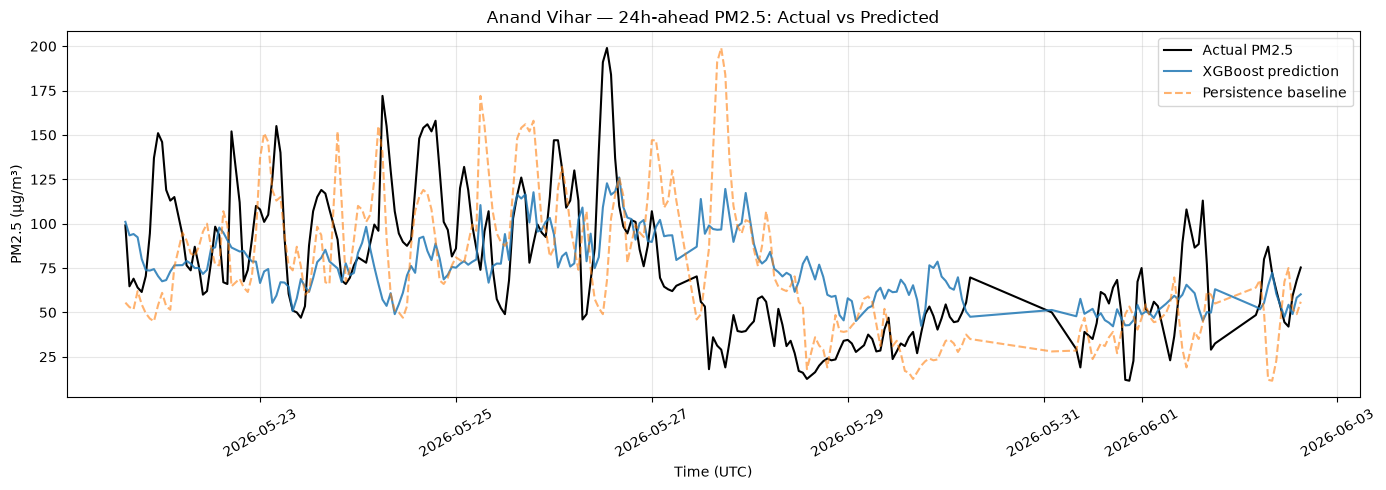

In [8]:
import matplotlib.pyplot as plt

# Pull the Anand Vihar result out of the results list
av_result = next(r for r in results if "Anand Vihar" in r["station"])

test_df_av = av_result["test_df"]
timestamps  = test_df_av["hour_utc"]
y_actual    = test_df_av["pm25_24h_ahead"].values
y_xgb       = av_result["y_test_pred"]
y_baseline  = test_df_av["pm25"].values   # persistence prediction

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(timestamps, y_actual,   label="Actual PM2.5",          color="black",      linewidth=1.5)
ax.plot(timestamps, y_xgb,      label="XGBoost prediction",    color="tab:blue",   alpha=0.85)
ax.plot(timestamps, y_baseline, label="Persistence baseline",  color="tab:orange", alpha=0.6, linestyle="--")

ax.set_title("Anand Vihar — 24h-ahead PM2.5: Actual vs Predicted")
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.legend()
ax.grid(alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()

# Save for the README
import os
os.makedirs("../data/processed/plots", exist_ok=True)
plt.savefig("../data/processed/plots/anand_vihar_actual_vs_predicted.png",
            dpi=120, bbox_inches="tight")
plt.show()

In [9]:
import os

print("Models:")
for f in sorted(os.listdir("../models")):
    print("  ", f)

print("\nResults table exists:", os.path.exists("../data/processed/model_results.csv"))
print("Plot exists:", os.path.exists("../data/processed/plots/anand_vihar_actual_vs_predicted.png"))

Models:
   xgb_anand_vihar.pkl
   xgb_first_station_rkpuram.pkl
   xgb_punjabi_bagh.pkl
   xgb_r_k_puram.pkl

Results table exists: True
Plot exists: True
